# Time Series Analysis

## RAS and Player Position By Draft Year

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import Checkbox, Output, Layout, GridBox

import sys
sys.path.append('../src')
from helpers import column_utils, csv_utils, merge_utils

In [91]:
df = csv_utils.csv_read('../data/cleaned/merged_ras_base_right_join_copy.csv', ',')

We will apply some filters to get the data we want to plot. 

- First we will filter out any of the Special Team positions, these include Long Snapper (LS) and Place Kicker (PK)
- Next, we will filter out any Undrafted players, since this analysis is only looking at NFL Draft activity
- Let's also filter out any players without a RAS score. We do not want the median RAS calculation to be skewed by players with missing scores.

In [92]:
df_filtered = df[~df['POS'].isin(['ST', 'LS', 'PK'])]
df_filtered = df_filtered[df_filtered['Round'].notna()]
df_filtered = df_filtered[df_filtered['RAS'].notna()]

grouping some positions together into one
- Defensive lineman
- Offnsive Lineman
- Safeties

In [93]:
df_filtered['POS'] = df_filtered['POS'].replace({'FS': 'DB', 'SS': 'DB', 'CB': 'DB', 'DE': 'DL', 'DT': 'DL', 'OC': 'OL', 'OG': 'OL', 'OT': 'OL', 'FB': 'RB'})

In [94]:
print(len(df_filtered[df_filtered['POS'] == 'FB']))
print(len(df_filtered[df_filtered['POS'] == 'RB']))

0
730


In [95]:
df_ras_position = df_filtered.groupby(['Year', 'POS'])['RAS'].median().reset_index()
df_ras_round = df_filtered.groupby(['Year', 'Round'])['RAS'].median().reset_index()

In [96]:
df_ras_round

,Year,Round,RAS
0,1987,1,8.270
1,1987,2,6.900
2,1987,3,5.000
3,1987,4,5.810
4,1987,5,6.320
...,...,...,...
275,2026,3,9.090
276,2026,4,9.050
277,2026,5,8.675
278,2026,6,7.890


In [97]:
years = df['Year'].unique()
years.sort()
print(years)

[1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000
 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026]


In [98]:
def plot_lines(df, filter_col, selection):
    if len(selection) == 0:
        display("Select at least one value")
        return
    
    col_dtype = df[filter_col].dtype

    try:
        selection = [col_dtype.type(v) for v in selection]
    except:
        selection = [int(v) if v.isdigit() else v for v in selection]
    df_ras_filter_col = df[df[filter_col].isin(selection)].groupby(['Year', filter_col])['RAS'].median().reset_index()
    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(data=df_ras_filter_col, x='Year', y='RAS', hue=filter_col)
    ax.legend(title=f"{'Position' if filter_col == 'POS' else 'Draft Round'} (Selected)", loc='upper left')
    plt.title(f"Median RAS of Drafted NFL Player by {'Position' if filter_col == 'POS' else 'Draft Round'} each Year")
    plt.xlabel("Year")
    plt.ylabel("Median RAS")
    plt.xticks(rotation=45, ticks=years)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [99]:
def interactive_line_plot_checkboxes(df, filter_col):
    values = sorted(df[filter_col].dropna().unique())
    checkboxes = [Checkbox(
            value=False,
            description=str(v)) for v in values]
    ui = GridBox(
    checkboxes,
    layout=Layout(
        grid_template_columns="repeat(4, 90px)",
        grid_gap="2px 5px",
        margin="0"
    )
    )
    out = Output()
    def update_plot(change):
        selected = [cb.description for cb in checkboxes if cb.value]
        out.clear_output(wait=True)
        with out:
            plot_lines(df, filter_col, selected)

    for cb in checkboxes:
        cb.unobserve_all()
        cb.observe(update_plot, "value")

    display(ui, out)

In [100]:

interactive_line_plot_checkboxes(df_ras_position, filter_col="POS")


GridBox(children=(Checkbox(value=False, description='DB'), Checkbox(value=False, description='DL'), Checkbox(v…

Output()

<Axes: xlabel='Year', ylabel='RAS'>

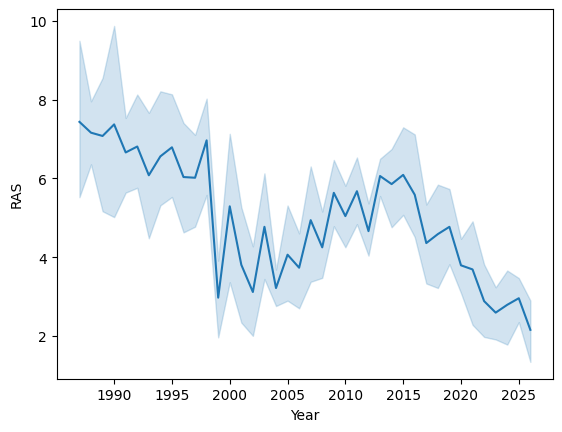

In [117]:
df_ras_position_variance = df_filtered.groupby(['POS', 'Year'])['RAS'].var().reset_index()
df_ras_round_variance = df_filtered.groupby(['Round', 'Year'])['RAS'].var().reset_index()


sns.lineplot(data=df_ras_round_variance, x='Year', y='RAS')


<Axes: xlabel='Year', ylabel='RAS'>

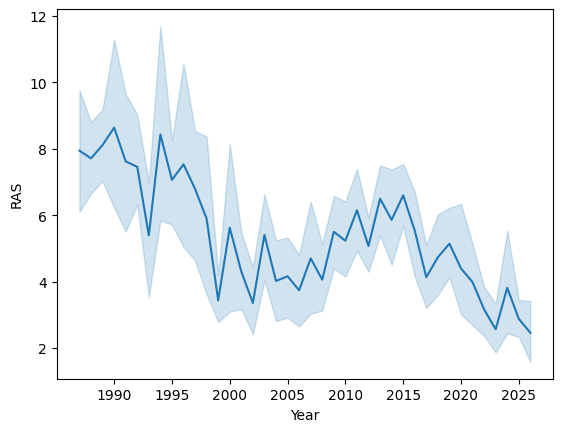

In [118]:
sns.lineplot(data=df_ras_position_variance, x='Year', y='RAS')

In [101]:
interactive_line_plot_checkboxes(df_ras_round, filter_col="Round")

GridBox(children=(Checkbox(value=False, description='1'), Checkbox(value=False, description='2'), Checkbox(val…

Output()